<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset successfully loaded!


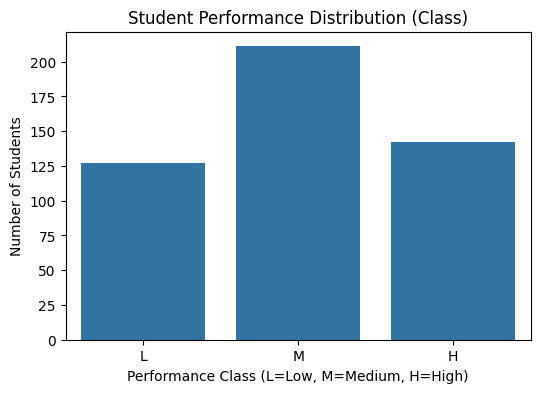

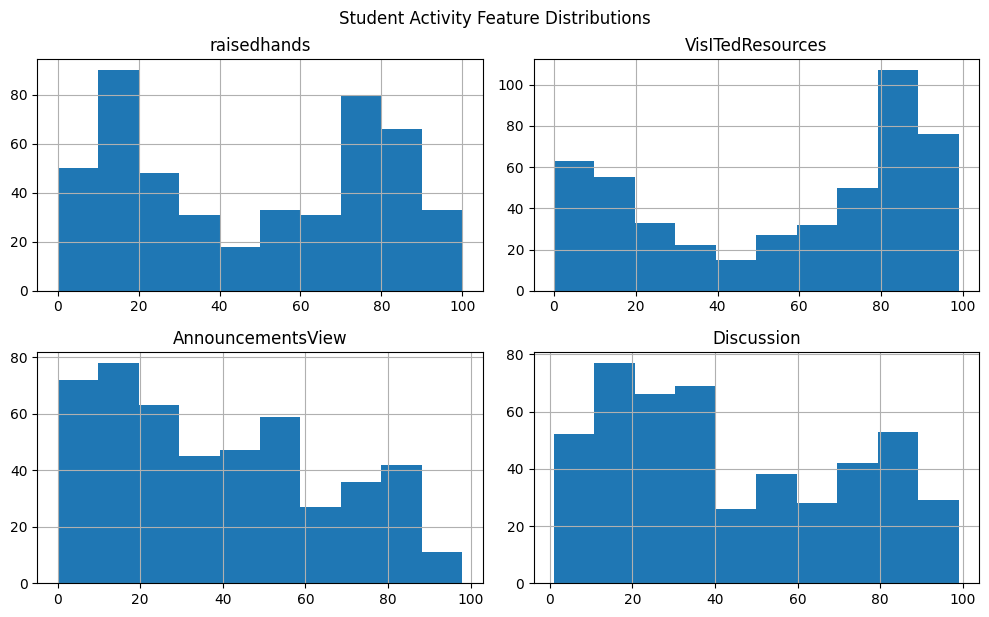

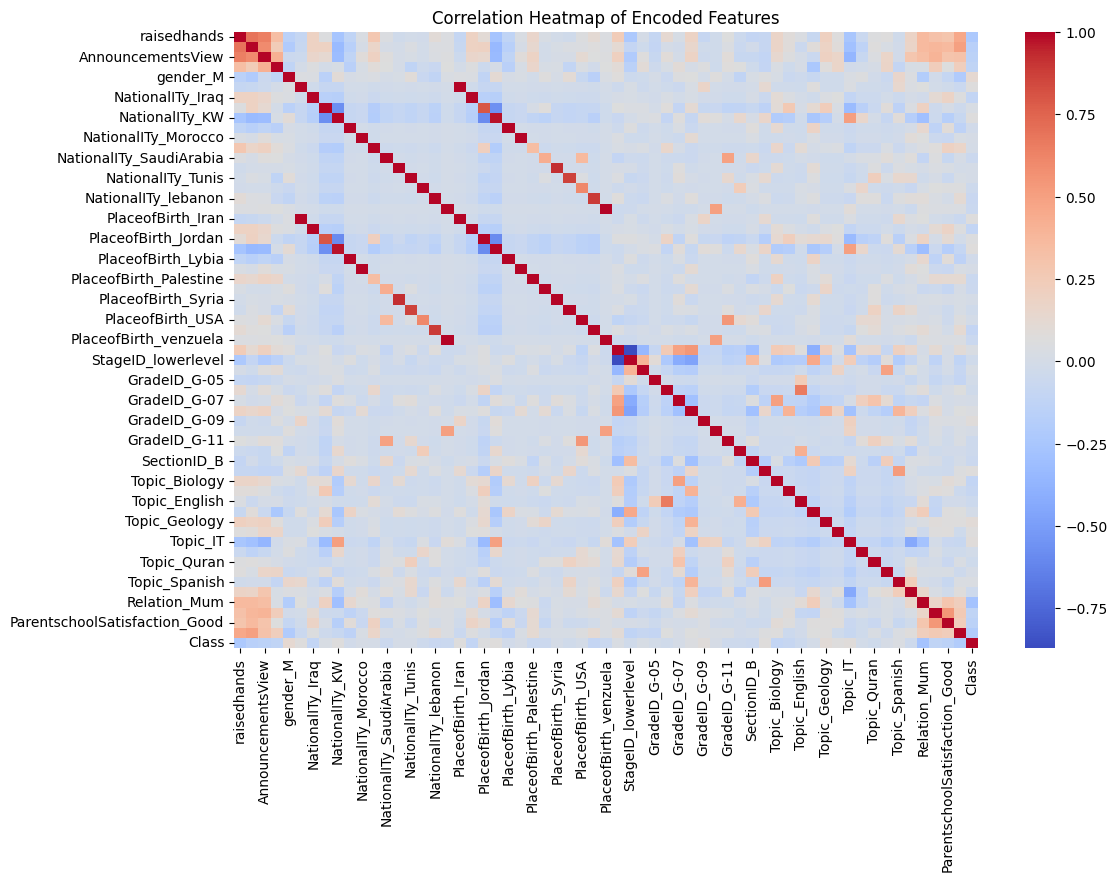


================ LOGISTIC REGRESSION ================
Confusion Matrix:
 [[19  0 10]
 [ 0 22  3]
 [ 6  6 30]]

Classification Report:
               precision    recall  f1-score   support

           H       0.76      0.66      0.70        29
           L       0.79      0.88      0.83        25
           M       0.70      0.71      0.71        42

    accuracy                           0.74        96
   macro avg       0.75      0.75      0.75        96
weighted avg       0.74      0.74      0.74        96


================ KNN ================
Confusion Matrix:
 [[15  0 14]
 [ 1 19  5]
 [14  8 20]]

Classification Report:
               precision    recall  f1-score   support

           H       0.50      0.52      0.51        29
           L       0.70      0.76      0.73        25
           M       0.51      0.48      0.49        42

    accuracy                           0.56        96
   macro avg       0.57      0.58      0.58        96
weighted avg       0.56      0.56    

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 1. LOAD & CLEAN DATASET
try:
    df = pd.read_csv("student.csv")
    df.columns = df.columns.str.strip()  # Clean column space issues
    print("Dataset successfully loaded!")
except FileNotFoundError:
    print("Error: 'student.csv' not found. Please upload the file.")

# 2. DATA VISUALIZATION
TARGET_COL = "Class"  # Corrected target column for this dataset

# Visual 1: Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COL, data=df, order=['L', 'M', 'H'])
plt.title("Student Performance Distribution (Class)")
plt.xlabel("Performance Class (L=Low, M=Medium, H=High)")
plt.ylabel("Number of Students")
plt.show()

# Visual 2: Numerical Feature Distributions
num_cols = ["raisedhands", "VisITedResources", "AnnouncementsView", "Discussion"]
df[num_cols].hist(bins=10, figsize=(10, 6))
plt.tight_layout()
plt.suptitle("Student Activity Feature Distributions", y=1.02)
plt.show()

# 3. FEATURE PREPROCESSING
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Encode Target Variable ('L', 'M', 'H' -> 0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# One-Hot Encode Categorical Features (Gender, Nationality, Topic, etc.)
X_encoded = pd.get_dummies(X, drop_first=True)

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pd.concat([X_encoded, pd.Series(y_encoded, name=TARGET_COL)], axis=1).corr(),
            cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Encoded Features")
plt.show()

# 4. TRAIN-TEST SPLIT & FEATURE SCALING
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. MODEL EVALUATION LOOP
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n================ {name.upper()} ================")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# 6. SUMMARY COMPARISON TABLE
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\n=== MODEL PERFORMANCE RANKING ===")
print(results_df.to_string(index=False))